#### DataEncoding means converting categorial value into numerical values so that define model for numerical values.

## Data Encoding

##### 1. Nominal/OHE Encoding
##### 2. Label and Ordinal Encoding
##### 3. Target Guided Ordinal Encoding

### 1.Nominal/ OHE(one hot encoding) Encoding

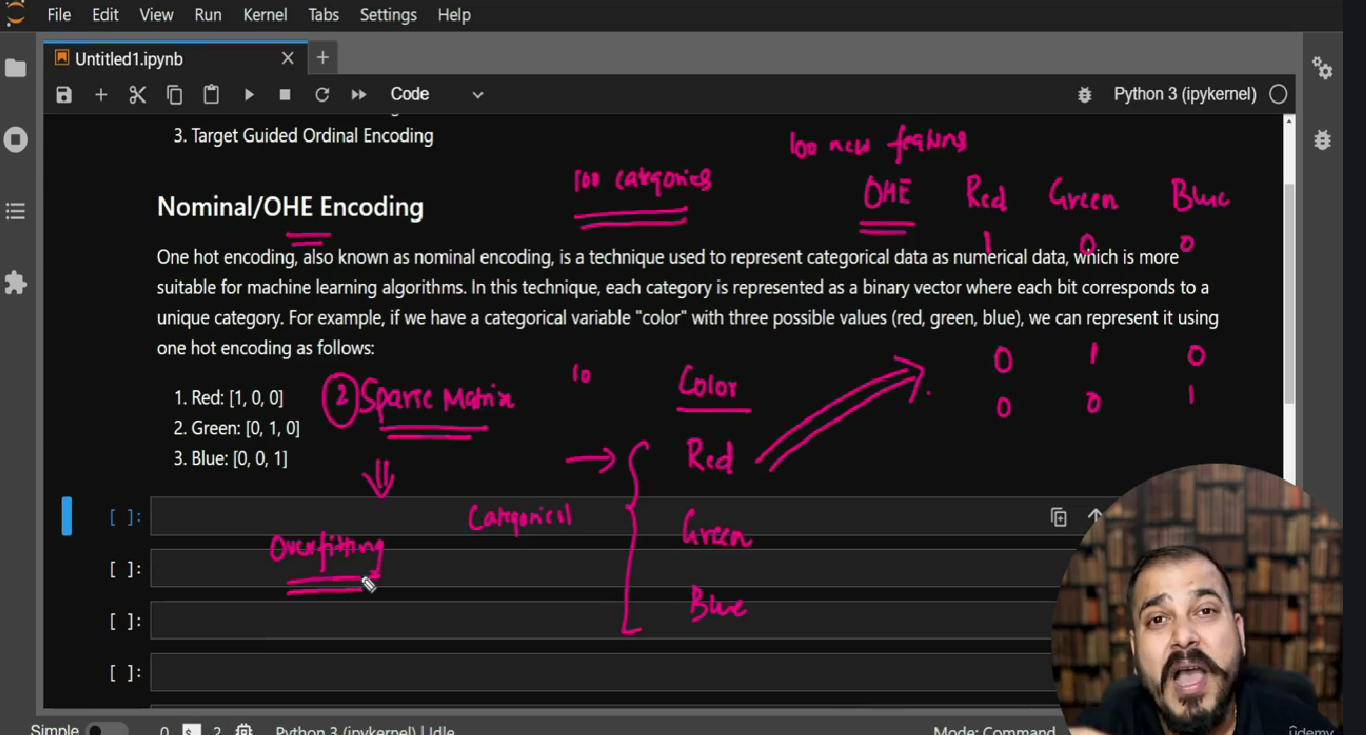

In [2]:
from IPython.display import Image, display
display(Image(filename=r"C:\Users\Rohit\Visual Studio Code- By Rohit\Data Analyst- Udemy\9. Feature Enginnering\image.png"))

In [4]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [5]:
## Create a simple dataframe

df= pd.DataFrame({
    'color':['red','blue','green','green','red','blue']
})

In [6]:
df.head()

,color
0,red
1,blue
2,green
3,green
4,red


In [7]:
## create an instance of onehotencoder

encoder=OneHotEncoder()

In [9]:
encoded=encoder.fit_transform(df[['color']]).toarray()      # This is alphabetaical order

In [10]:
import pandas as pd
encoder_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())

In [11]:
encoder_df

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0


In [ ]:
# For new data
encoder.transform([['blue']]).toarray()

c:\Users\Rohit\Visual Studio Code- By Rohit\Data Analyst- Udemy\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[1., 0., 0.]])

In [13]:
pd.concat([df,encoder_df],axis=1)

,color,color_blue,color_green,color_red
0,red,0.0,0.0,1.0
1,blue,1.0,0.0,0.0
2,green,0.0,1.0,0.0
3,green,0.0,1.0,0.0
4,red,0.0,0.0,1.0
5,blue,1.0,0.0,0.0


In [14]:
import seaborn as sns
sns.load_dataset('tips')

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### 2. Label and Ordinal Encoding

In [1]:
from sklearn.preprocessing import LabelEncoder
lbl_encoder=LabelEncoder()

In [6]:
lbl_encoder.fit_transform(df[['color']])

c:\Users\Rohit\Visual Studio Code- By Rohit\Data Analyst- Udemy\venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([2, 0, 1, 1, 2, 0])

In [7]:
lbl_encoder.transform([['red']])

c:\Users\Rohit\Visual Studio Code- By Rohit\Data Analyst- Udemy\venv\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([2])

In [8]:
lbl_encoder.transform([['blue']])

c:\Users\Rohit\Visual Studio Code- By Rohit\Data Analyst- Udemy\venv\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([0])

In [9]:
lbl_encoder.transform([['green']])

c:\Users\Rohit\Visual Studio Code- By Rohit\Data Analyst- Udemy\venv\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([1])

#### Ordinal Encoding

In [11]:
from sklearn.preprocessing import OrdinalEncoder

In [13]:
## Create sample dataframe with an ordinal variable

df= pd.DataFrame({
    'size':['small','medium','large','medium','small','large']
})

In [14]:
df

,size
0,small
1,medium
2,large
3,medium
4,small
5,large


In [16]:
## Assign Ranking of those size customly

## Create an instance of OrdinalEncoder and then fit_transform

encoder=OrdinalEncoder(categories=[['small','medium','large']])

In [17]:
encoder.fit_transform(df[['size']])

array([[0.],
       [1.],
       [2.],
       [1.],
       [0.],
       [2.]])

In [18]:
encoder.transform([['small']])

c:\Users\Rohit\Visual Studio Code- By Rohit\Data Analyst- Udemy\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


array([[0.]])

#### Traget Guided Ordinal Encoding

In [21]:
import pandas as pd

# Create a sample dataframe with a categorical variable and a target variable

df= pd.DataFrame({
    'city':['New York','London','Paris','Tokyo','New York','Paris'],
    'price': [200,150,300,250,180,320]
})

In [22]:
df

,city,price
0,New York,200
1,London,150
2,Paris,300
3,Tokyo,250
4,New York,180
5,Paris,320


In [25]:
mean_price=df.groupby('city')['price'].mean().to_dict()

In [26]:
mean_price

{'London': 150.0, 'New York': 190.0, 'Paris': 310.0, 'Tokyo': 250.0}

In [27]:
df['city_encoded']=df['city'].map(mean_price)

In [28]:
df

,city,price,city_encoded
0,New York,200,190.0
1,London,150,150.0
2,Paris,300,310.0
3,Tokyo,250,250.0
4,New York,180,190.0
5,Paris,320,310.0


In [29]:
df[['price','city_encoded']]

,price,city_encoded
0,200,190.0
1,150,150.0
2,300,310.0
3,250,250.0
4,180,190.0
5,320,310.0


In [ ]:
import seaborn as sns
sns.